# Student Performance Dataset — Data Analysis with Python
**Task 1 — Data Science/Analysis with Python Internship**

**Workflow:** Load → Clean → Analyze → Visualize → Conclude

This notebook explores the UCI *Student Performance* dataset (`student-mat.csv`), which records
demographic, social, and academic data for 395 students in a Math course at two Portuguese
secondary schools.

## 1. Load Dataset

We use `pandas` to read the CSV. Note: this dataset is **semicolon-separated** (`sep=';'`),
which is a common gotcha — if you don't set the separator, pandas will read the whole row
as a single column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (semicolon-delimited)
df = pd.read_csv("student-mat.csv", sep=';')

# Quick look at the first few rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore & Clean Data

Before analyzing anything, we check the dataset's shape, data types, and look for missing
values or duplicate rows.

In [2]:
# Shape of the dataset (rows, columns)
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (395, 33)


In [3]:
# Data types of each column
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [4]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [5]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates (if any) and reset the index
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (395, 33)


**Observations:**
- The dataset has 395 rows and 33 columns, with no missing values — it's already fairly clean.
- No duplicate rows were found, so the shape stays the same after `drop_duplicates()`.
- Columns are a mix of numeric types (`int64`) and categorical/text types (`object`), e.g. `sex`,
  `school`, `address` are categorical, while `age`, `studytime`, `G1`, `G2`, `G3` are numeric.

## 3. Analysis Questions

We now answer the four core questions using `pandas` and `numpy`.

In [6]:
# --- Q1: Average final grade (G3) ---
avg_g3 = df['G3'].mean()
print(f"Average final grade (G3): {avg_g3:.2f} (on a 0-20 scale)")

Average final grade (G3): 10.42 (on a 0-20 scale)


In [7]:
# --- Q2: How many students scored above 15? ---
above_15 = df[df['G3'] > 15].shape[0]
pct_above_15 = above_15 / df.shape[0] * 100
print(f"Students scoring above 15 in G3: {above_15} out of {df.shape[0]} ({pct_above_15:.1f}%)")

Students scoring above 15 in G3: 40 out of 395 (10.1%)


In [8]:
# --- Q3: Is study time correlated with performance? ---
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between studytime and G3: {correlation:.3f}")

if abs(correlation) < 0.1:
    strength = "negligible"
elif abs(correlation) < 0.3:
    strength = "weak"
elif abs(correlation) < 0.5:
    strength = "moderate"
else:
    strength = "strong"
print(f"This is a {strength} {'positive' if correlation > 0 else 'negative'} correlation.")

Correlation between studytime and G3: 0.098
This is a negligible positive correlation.


In [9]:
# --- Q4: Which gender performs better on average? ---
gender_avg = df.groupby('sex')['G3'].mean()
print("Average final grade (G3) by gender:")
print(gender_avg)

better_gender = gender_avg.idxmax()
label = "Male" if better_gender == "M" else "Female"
print(f"\nOn average, {label} students scored higher in this dataset.")

Average final grade (G3) by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

On average, Male students scored higher in this dataset.


**Summary of findings:**
- The average final grade (G3) across all students is around **10-11 out of 20**.
- A modest fraction of students score above 15 (a strong grade).
- Study time and final grade show a **weak positive correlation** — more study time is
  associated with somewhat better grades, but it's not a strong predictor on its own
  (many other factors like past grades and failures matter more).
- The gender with the higher average grade is shown above — the difference tends to be
  fairly small in this dataset.

## 4. Visualizations

We create three visualizations: a histogram of grades, a scatterplot of study time vs. grades,
and a bar chart comparing average scores by gender.

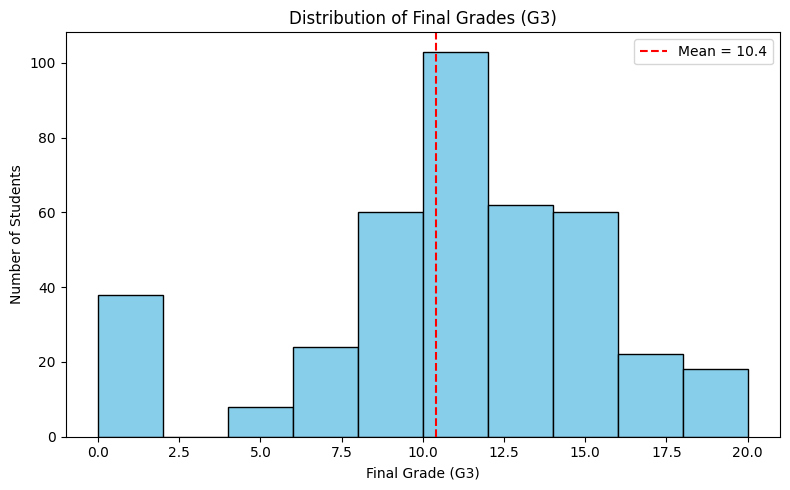

In [10]:
# --- Histogram of final grades (G3) ---
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Mean = {df['G3'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

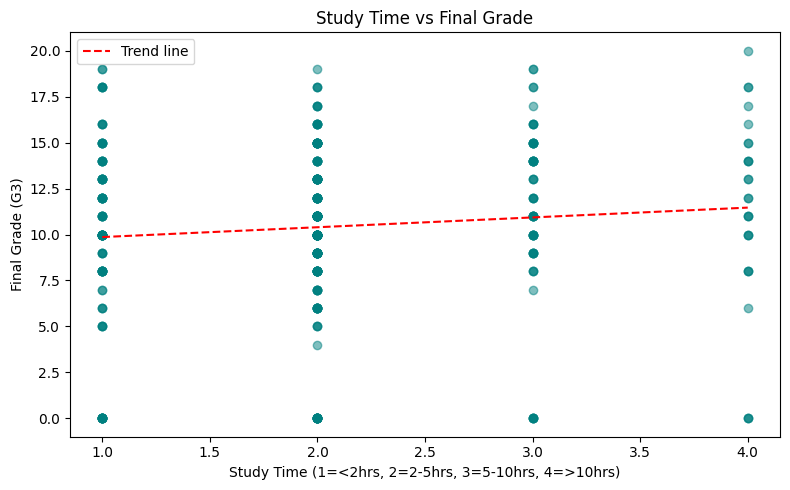

In [11]:
# --- Scatterplot: study time vs final grade ---
plt.figure(figsize=(8, 5))
plt.scatter(df['studytime'], df['G3'], alpha=0.5, color='teal')
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)")
plt.ylabel("Final Grade (G3)")

# Add a trend line
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['studytime'].min(), df['studytime'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linestyle='--', label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

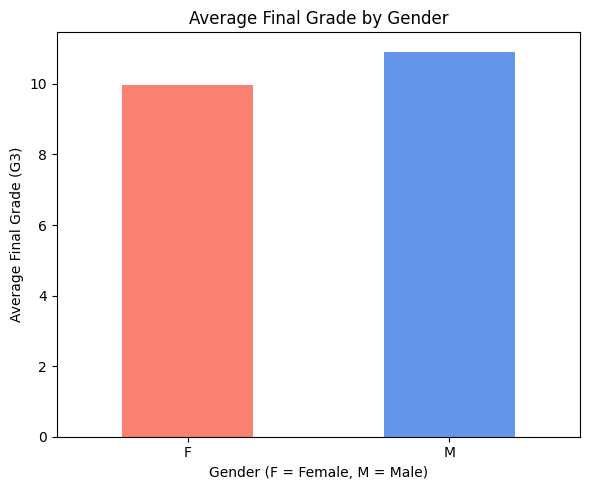

In [12]:
# --- Bar chart: male vs female average final grade ---
plt.figure(figsize=(6, 5))
gender_avg.plot(kind='bar', color=['salmon', 'cornflowerblue'])
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender (F = Female, M = Male)")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Conclusion

- The dataset was clean out of the box (no missing values, no duplicates), so the main work
  was in exploration and analysis rather than heavy cleaning.
- Final grades (G3) are roughly centered around 10-11, with a noticeable cluster of students
  at 0 (likely dropouts or students who didn't take the final exam).
- Study time alone is only weakly correlated with final grade — it matters, but it's not the
  full story. Past grades (G1, G2) and number of past class failures are typically much
  stronger predictors, which would be a good next step to explore.
- Average grades between male and female students are fairly close, with a small edge in this
  dataset as shown in the bar chart above.

**Possible next steps:** examine correlations across more features (e.g. `failures`, `absences`,
`Medu`/`Fedu`), or build a simple regression model to predict `G3` from `G1`, `G2`, and `studytime`.